In [1]:
import timeit as t
from timeit import default_timer as timer
import numpy as np
import matplotlib.pyplot as plt
#### %matplotlib notebook
%matplotlib inline

# Setup styles for plotting
style_list = ['default', 'classic'] + sorted(
        style for style in plt.style.available if style != 'classic')
plt.style.use(style_list[10])
print(style_list)

['default', 'classic', 'Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [2]:
# 2.1 Function to find Nth Fibonacci term
def FibonacciRec(N:int):
    # Base Case
    if (N < 2):
        return N

    # Recursively computing the term
    # using recurrence relation
    return FibonacciRec(N - 1) + FibonacciRec(N - 2)

# Test fibonacci: compute results for N 1 .. 20
for n in range(0,20):
    print(n, " Fib:", FibonacciRec(n))


0  Fib: 0
1  Fib: 1
2  Fib: 1
3  Fib: 2
4  Fib: 3
5  Fib: 5
6  Fib: 8
7  Fib: 13
8  Fib: 21
9  Fib: 34
10  Fib: 55
11  Fib: 89
12  Fib: 144
13  Fib: 233
14  Fib: 377
15  Fib: 610
16  Fib: 987
17  Fib: 1597
18  Fib: 2584
19  Fib: 4181


### 2.2 Execution time

Example:
`t.timeit('quicksort(data)','from __main__ import data,quicksort', number = num)`


In [3]:
# Measure execution time : 
fibNumber = 40

t_fib = t.timeit('FibonacciRec(fibNumber)','from __main__ import fibNumber, FibonacciRec', number = 1)

print('Fibonnaci for ', fibNumber, ' execution time sec: ', t_fib)

Fibonnaci for  40  execution time sec:  22.387415800010785


[9.00006853e-07 1.40001066e-06 1.99989881e-06 1.31999841e-05
 1.47900078e-04 1.48699991e-03 1.64370000e-02 1.78176600e-01
 2.38783090e+00]


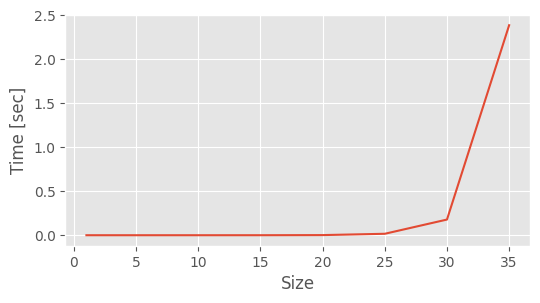

In [4]:
# 2.3 Plot graph of Fibonnaci execution time

size = np.array([]); #this array will store the current dataset size
t_list = np.array([]); #store processing time here
num = 1 #evaluation repetition (keep at 1 for now)

n_list = [1,3,5,10,15,20,25,30,35]
#
for n in n_list:
    fibNumber = n
    t_fib = t.timeit('FibonacciRec(fibNumber)','from __main__ import fibNumber, FibonacciRec', number = 1)
    t_list = np.append(t_list, t_fib)
print(t_list)


ax = plt.figure(figsize=[6,3])
plt.plot(n_list,t_list)
plt.xlabel('Size')
plt.ylabel('Time [sec]')
plt.show()


In [5]:
# 2.4 Class for algorithm testing
from utils import Algorithm

# Testing
a = Algorithm()
a.run()


Algorithm.run_once, operations:  10
 >>  0 , msec: 0.536 , operations:  10
 >>>  Algorithm  > Total run() sec:  0.0006059000734239817  Avg iter msec: 0.6059000734239817


{'name': 'Algorithm',
 'avg_msec': 0.6059000734239817,
 'avg_O': 10.0,
 'niter': 1,
 'output': []}

In [6]:
# 2.5  Fibonnaci algoritem z uporabo Alogrithm

class FibonacciRecursion(Algorithm):
    def __init__(self):
        self.name = "FibonacciRecursion"

    # Function to find Nth Fibonacci term
    def FibonacciR(self, N:int):
        # Count each call of the function
        self.count_op += 1

        # Base Case
        if (N < 2):
            return N

        # Recursively computing the term
        # using recurrence relation
        return self.FibonacciR(N - 1) + self.FibonacciR(N - 2)

    def run_once(self):

        N = self.data_params['N']
        self.result_data = self.FibonacciR(N)

        return self.result_data


s = FibonacciRecursion()
# calculate Fib. number of 10
s.data_params = {'N': 10}
# Test 10 times
print('Test result: ', s.run(10))


 >>  0 , msec: 0.055 , operations:  177
 >>  1 , msec: 0.057 , operations:  177
 >>  2 , msec: 0.052 , operations:  177
 >>  3 , msec: 0.061 , operations:  177
 >>  4 , msec: 0.048 , operations:  177
 >>  5 , msec: 0.045 , operations:  177
 >>  6 , msec: 0.050 , operations:  177
 >>  7 , msec: 0.048 , operations:  177
 >>  8 , msec: 0.059 , operations:  177
 >>  9 , msec: 0.048 , operations:  177
 >>>  FibonacciRecursion  > Total run() sec:  0.0014657999854534864  Avg iter msec: 0.14657999854534864
Test result:  {'name': 'FibonacciRecursion', 'avg_msec': 0.14657999854534864, 'avg_O': 177.0, 'niter': 10, 'output': 55}


 >>  0 , msec: 0.007 , operations:  1
 >>>  FibonacciRecursion  > Total run() sec:  0.0006998000899329782  Avg iter msec: 0.6998000899329782
 >>  0 , msec: 0.006 , operations:  5
 >>>  FibonacciRecursion  > Total run() sec:  7.349997758865356e-05  Avg iter msec: 0.07349997758865356
 >>  0 , msec: 0.006 , operations:  15
 >>>  FibonacciRecursion  > Total run() sec:  6.420002318918705e-05  Avg iter msec: 0.06420002318918705
 >>  0 , msec: 0.052 , operations:  177
 >>>  FibonacciRecursion  > Total run() sec:  0.00011470005847513676  Avg iter msec: 0.11470005847513676
 >>  0 , msec: 0.621 , operations:  1973
 >>>  FibonacciRecursion  > Total run() sec:  0.0006870999932289124  Avg iter msec: 0.6870999932289124
 >>  0 , msec: 6.459 , operations:  21891
 >>>  FibonacciRecursion  > Total run() sec:  0.006564900046214461  Avg iter msec: 6.564900046214461
 >>  0 , msec: 52.459 , operations:  242785
 >>>  FibonacciRecursion  > Total run() sec:  0.05252170003950596  Avg iter msec: 52.5217000395059

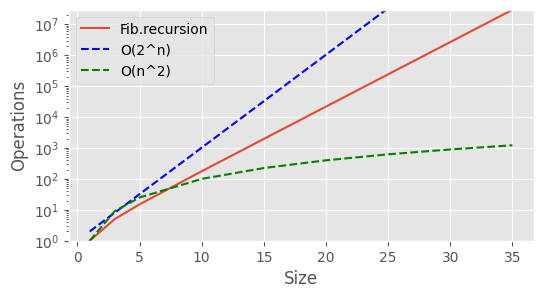

In [7]:
# 2.6 Testing Fibonacci recursion

size = np.array([]) #this array will store the current dataset size
t_list = np.array([]) #store processing time here
oper_list = np.array([]) #store processing operations here
num = 1 # evaluation repetition (keep at 1 for now)

n_list = [1,3,5,10,15,20,25,30,35]

s = FibonacciRecursion()
s.data_params = {'N': 1}

for n in n_list:
    s.data_params['N'] = n
    result = s.run(ntimes=num)
    size = np.append(size, n)
    oper_list = np.append(oper_list, result['avg_O'])


ax = plt.figure(figsize=[6,3])
plt.plot(size, oper_list, label='Fib.recursion')

O2n = [2**n for n in n_list]
On2 = [n*n for n in n_list]
plt.plot(size, O2n, 'b--', label='O(2^n)')
plt.plot(size, On2, 'g--', label='O(n^2)')

plt.ylim([1, max(oper_list)])
plt.xlabel('Size')
plt.ylabel('Operations')
plt.legend()
plt.yscale('log')

plt.show()

In [8]:
# 2.7 Fibonnaci algorithm optimized

class FibonacciOptimized(Algorithm):
    def __init__(self):
        self.name = "FibonacciOptimized"

    # Function to find Nth Fibonacci term
    def Fibonacci(self, N):
        f=[0]*(N + 2)
        # 0th and 1st number of the
        # series are 0 and 1
        f[0] = 0
        f[1] = 1
        # Iterate over the range [2, N]
        for i in range(2,N+1) :
            self.count_op += 1
            # Add the previous 2 numbers
            # in the series and store it
            f[i] = f[i - 1] + f[i - 2]
        # Return Nth Fibonacci Number
        return f[N]

    def run_once(self):

        N = self.data_params['N']
        self.result_data = self.Fibonacci(N)

        return self.result_data


s = FibonacciOptimized()
s.data_params = {'N': 10000}
print(s.run(1))



 >>  0 , msec: 4.871 , operations:  9999
 >>>  FibonacciOptimized  > Total run() sec:  0.00513669999781996  Avg iter msec: 5.13669999781996
{'name': 'FibonacciOptimized', 'avg_msec': 5.13669999781996, 'avg_O': 9999.0, 'niter': 1, 'output': 3364476487643178326662161200510754331030214846068006390656476997468008144216666236815559551363373402558206533268083615937373479048386526826304089246305643188735454436955982749160660209988418393386465273130008883026923567361313511757929743785441375213052050434770160226475831890652789085515436615958298727968298751063120057542878345321551510387081829896979161312785626503319548714021428753269818796204693609787990035096230229102636813149319527563022783762844154036058440257211433496118002309120828704608892396232883546150577658327125254609359112820392528539343462090424524892940390170623388899108584106518317336043747073790855263176432573399371287193758774689747992630583706574283016163740896917842637862421283525811282051637029808933209990570792006436742620238

 >>  0 , msec: 0.003 , operations:  0
 >>>  FibonacciOptimized  > Total run() sec:  0.00032549991738051176  Avg iter msec: 0.32549991738051176
 >>  0 , msec: 0.006 , operations:  2
 >>>  FibonacciOptimized  > Total run() sec:  6.230000872164965e-05  Avg iter msec: 0.06230000872164965
 >>  0 , msec: 0.005 , operations:  4
 >>>  FibonacciOptimized  > Total run() sec:  5.889998283237219e-05  Avg iter msec: 0.05889998283237219
 >>  0 , msec: 0.005 , operations:  9
 >>>  FibonacciOptimized  > Total run() sec:  5.0200033001601696e-05  Avg iter msec: 0.050200033001601696
 >>  0 , msec: 0.005 , operations:  14
 >>>  FibonacciOptimized  > Total run() sec:  4.710000939667225e-05  Avg iter msec: 0.04710000939667225
 >>  0 , msec: 0.024 , operations:  99
 >>>  FibonacciOptimized  > Total run() sec:  5.180004518479109e-05  Avg iter msec: 0.05180004518479109
 >>  0 , msec: 0.124 , operations:  499
 >>>  FibonacciOptimized  > Total run() sec:  0.00015449989587068558  Avg iter msec: 0.1544998958706855

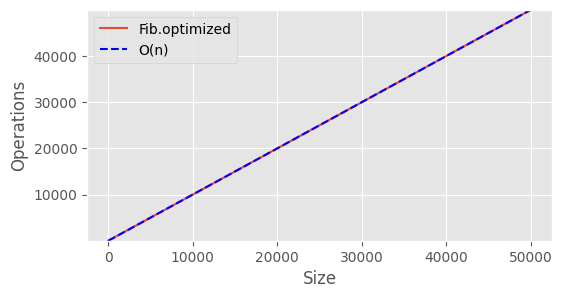

In [22]:
# 2.7 Testing Fibonacci optimized

size = np.array([]) #this array will store the current dataset size
t_list = np.array([]) #store processing time here
oper_list = np.array([]) #store processing operations here
num = 1 # evaluation repetition (keep at 1 for now)

n_list = [1,3,5,10,15,100,500,1000,10000,50000]

s = FibonacciOptimized()
s.data_params = {'N': 1}

for n in n_list:
    s.data_params['N'] = n
    result = s.run(ntimes=num)
    size = np.append(size, n)
    oper_list = np.append(oper_list, result['avg_O'])


ax = plt.figure(figsize=[6,3])
plt.plot(size, oper_list, label='Fib.optimized')

On = [n for n in n_list]
#On2 = [n*n for n in n_list]
plt.plot(size, On, 'b--', label='O(n)')
#plt.plot(size, On2, 'g--', label='O(n^2)')

plt.ylim([1, max(oper_list)])
plt.xlabel('Size')
plt.ylabel('Operations')
plt.legend()
#plt.yscale('log')

plt.show()


### Sorting algorithms

The task that we will be solving in this exercise will be a simple sorting of numbers in ascending order. Again when dealing with such a task, we must consider several scenarios (at least if we want to be objective in our measurements):
* **Optimal** - in this case the numbers are sorted allready, which means that the algorithm must only detect this as quick as possible.
* **Worst** - in this case the numbers are sorted but in a reverse order.
* **Normal** - the numbers are sorted randomly


In [23]:
def insertionSort2(array):
    d = array.copy()
    for j in range(1, len(d)):
        key = d[j]
        i = j - 1
        while i >= 0 and d[i] > key:
            d[i + 1] = d[i]
            i = i - 1
        d[i + 1] = key
    return d

In [24]:
# Create data set
def createSet(type = None, size = 100):
    if type == 1:  #return numbers sorted in ascening order -> best case
        return np.linspace(1,size,size).tolist() 
    elif type == 2: #return numbers in descending order -> wost case
        return np.linspace(size,1,size).tolist()
    else: #return a random assortment of numbers
        return (np.trunc(np.absolute(size*10/2.0 + size*10/5.0*np.random.randn(size)))/10).tolist()

In [27]:
# 3.1 Try type parameters : 1..3, print data
print("type=1 : ", createSet(1,20))
print("Normal case: random : ", createSet(0,20))
print("Worst case: descending : ", createSet(2,20))

type=1 :  [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0]
Normal case: random :  [2.7, 1.1, 10.7, 12.2, 11.2, 16.8, 8.4, 7.2, 15.2, 11.5, 3.9, 3.6, 7.3, 8.8, 4.9, 9.0, 12.9, 7.4, 8.3, 15.9]
Worst case: descending :  [20.0, 19.0, 18.0, 17.0, 16.0, 15.0, 14.0, 13.0, 12.0, 11.0, 10.0, 9.0, 8.0, 7.0, 6.0, 5.0, 4.0, 3.0, 2.0, 1.0]


In [28]:
# 3.3 Test insertionSort2
data = createSet(0, size=100)
result = insertionSort2(data)
print(data)
print(result)


[71.7, 18.1, 100.7, 20.0, 81.8, 48.0, 78.5, 50.9, 34.7, 26.9, 53.4, 53.2, 28.9, 70.1, 41.9, 69.8, 56.9, 44.0, 76.4, 35.1, 31.5, 45.3, 78.3, 55.4, 50.2, 40.6, 50.1, 64.7, 34.2, 22.7, 70.1, 70.3, 54.8, 37.0, 91.1, 29.1, 37.5, 58.8, 44.2, 85.9, 44.0, 70.6, 40.2, 43.4, 16.2, 72.5, 66.7, 46.1, 53.7, 89.0, 48.9, 77.6, 50.1, 59.1, 32.8, 58.3, 32.9, 60.3, 52.1, 51.0, 58.3, 21.9, 39.6, 17.7, 40.1, 55.7, 31.7, 61.5, 70.5, 51.2, 54.8, 48.8, 43.5, 34.6, 35.4, 77.5, 33.1, 18.8, 51.9, 95.1, 92.1, 86.6, 45.2, 41.4, 71.8, 38.9, 61.9, 75.6, 59.9, 31.1, 72.6, 50.6, 43.9, 25.2, 40.1, 41.9, 23.2, 72.6, 54.0, 53.5]
[16.2, 17.7, 18.1, 18.8, 20.0, 21.9, 22.7, 23.2, 25.2, 26.9, 28.9, 29.1, 31.1, 31.5, 31.7, 32.8, 32.9, 33.1, 34.2, 34.6, 34.7, 35.1, 35.4, 37.0, 37.5, 38.9, 39.6, 40.1, 40.1, 40.2, 40.6, 41.4, 41.9, 41.9, 43.4, 43.5, 43.9, 44.0, 44.0, 44.2, 45.2, 45.3, 46.1, 48.0, 48.8, 48.9, 50.1, 50.1, 50.2, 50.6, 50.9, 51.0, 51.2, 51.9, 52.1, 53.2, 53.4, 53.5, 53.7, 54.0, 54.8, 54.8, 55.4, 55.7, 56.9, 58.3, 5

In [29]:
# Measurement class for algorithm complexity, insertion sort

class InsertionSort(Algorithm):
    def __init__(self):
        self.name = "Insertion Sort"

    def create_data(self):
        sz = self.data_params.get('size')
        typ = self.data_params.get('type')
        if (sz != None) and (typ != None):
            self.input_data = createSet(size = sz, type = typ)
        else:
            self.input_data = createSet()

    def insertionSort(self, array):
        d = array.copy()
        for j in range(1, len(d)):
            key = d[j]
            i = j - 1
            while i >= 0 and d[i] > key:
                self.count_op+=1
                d[i + 1] = d[i]
                i = i - 1
            d[i + 1] = key
        return d


    def run_once(self):
        self.result_data = self.insertionSort(self.input_data)
        return self.result_data

In [32]:
# 3.4 Test InsertionSort class

s = InsertionSort()
s.data_params = {'size': 1000, 'type': 1}

test_results = s.run(2)

print('Unsorted data: ', s.input_data)
#print('Sorted data: ', s.result_data)

print('\n TEST RESULTS :  ', test_results)


 >>  0 , msec: 0.339 , operations:  0
 >>  1 , msec: 0.387 , operations:  0
 >>>  Insertion Sort  > Total run() sec:  0.0009854999370872974  Avg iter msec: 0.4927499685436487
Unsorted data:  [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 36.0, 37.0, 38.0, 39.0, 40.0, 41.0, 42.0, 43.0, 44.0, 45.0, 46.0, 47.0, 48.0, 49.0, 50.0, 51.0, 52.0, 53.0, 54.0, 55.0, 56.0, 57.0, 58.0, 59.0, 60.0, 61.0, 62.0, 63.0, 64.0, 65.0, 66.0, 67.0, 68.0, 69.0, 70.0, 71.0, 72.0, 73.0, 74.0, 75.0, 76.0, 77.0, 78.0, 79.0, 80.0, 81.0, 82.0, 83.0, 84.0, 85.0, 86.0, 87.0, 88.0, 89.0, 90.0, 91.0, 92.0, 93.0, 94.0, 95.0, 96.0, 97.0, 98.0, 99.0, 100.0, 101.0, 102.0, 103.0, 104.0, 105.0, 106.0, 107.0, 108.0, 109.0, 110.0, 111.0, 112.0, 113.0, 114.0, 115.0, 116.0, 117.0, 118.0, 119.0, 120.0, 121.0, 122.0, 123.0, 124.0, 125.0, 126.0, 127.0, 128.0, 129.0, 130.0, 131.0,

 >>  0 , msec: 0.063 , operations:  0
 >>>  Insertion Sort  > Total run() sec:  0.0003901999443769455  Avg iter msec: 0.3901999443769455
 >>  0 , msec: 0.045 , operations:  0
 >>>  Insertion Sort  > Total run() sec:  7.870001718401909e-05  Avg iter msec: 0.07870001718401909
 >>  0 , msec: 0.026 , operations:  0
 >>>  Insertion Sort  > Total run() sec:  5.6399963796138763e-05  Avg iter msec: 0.05639996379613876
 >>  0 , msec: 0.027 , operations:  0
 >>>  Insertion Sort  > Total run() sec:  5.510007031261921e-05  Avg iter msec: 0.05510007031261921
 >>  0 , msec: 0.040 , operations:  0
 >>>  Insertion Sort  > Total run() sec:  6.989995017647743e-05  Avg iter msec: 0.06989995017647743
 >>  0 , msec: 0.052 , operations:  0
 >>>  Insertion Sort  > Total run() sec:  7.979990914463997e-05  Avg iter msec: 0.07979990914463997
 >>  0 , msec: 0.102 , operations:  0
 >>>  Insertion Sort  > Total run() sec:  0.00013310008216649294  Avg iter msec: 0.13310008216649294
 >>  0 , msec: 0.178 , operations

C:\Users\janezzaletelj\AppData\Local\Temp\ipykernel_21780\2716345043.py:29: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.ylim([0, max(oper_list)])


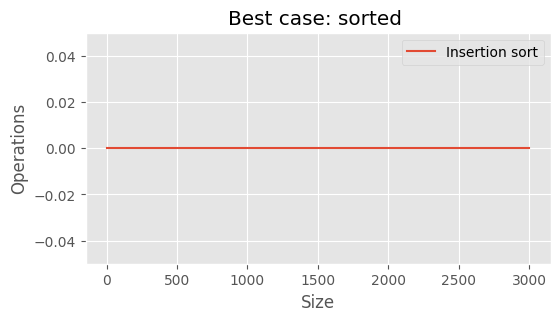

In [43]:
# 3.5 Complexity of Insertion sort
size = np.array([]); #this array will store the current dataset size
t_list = np.array([]); #store processing time here
oper_list = np.array([]); #store processing time here
num = 1 #evaluation repetition (keep at 1 for now)

n_list = [1,10,20,50,100, 200, 500, 1000,3000]

s = InsertionSort()
s.data_params['type'] = 1 # 1 best # 2 worst case # random

# Loop over all dataset sizes
for n in n_list:
    s.data_params['size'] = n
    result = s.run(ntimes=num)
    size = np.append(size, n)
    oper_list = np.append(oper_list, result['avg_O'])

# Plot graph
ax = plt.figure(figsize=[6,3])
plt.plot(size, oper_list, label='Insertion sort')

Onlogn = [n*np.log10(n) for n in n_list]
On2 = [n*n for n in n_list]

#plt.plot(size, On2, 'b--', label='O(n**2)')
#plt.plot(size, Onlogn, 'g--', label='O(n logn)')

plt.ylim([0, max(oper_list)])
plt.xlabel('Size')
plt.ylabel('Operations')
plt.legend()
# plt.yscale('log')
plt.title("Best case: sorted ")
plt.show()


In [44]:
def quicksort(arr):
    """ Quicksort a list

    :type arr: list
    :param arr: List to sort
    :returns: list -- Sorted list
    """
    if len(arr) <= 1:
        return arr
    else:
        return quicksort([x for x in arr[1:] if x<arr[0]]) + [arr[0]] + quicksort([x for x in arr[1:] if x>=arr[0]])

In [45]:
class QuickSort(Algorithm):
    def __init__(self):
        self.name = "Quick Sort"

    def create_data(self):
        sz = self.data_params.get('size')
        typ = self.data_params.get('type')
        if (sz != None) and (typ != None):
            self.input_data = createSet(size = sz, type = typ)
        else:
            self.input_data = createSet()


    # Function to find the partition position
    def partition(self, array, low, high):
    
        # Choose the rightmost element as pivot
        pivot = array[high]
    
        # Pointer for greater element
        i = low - 1
    
        # Traverse through all elements
        # compare each element with pivot
        for j in range(low, high):
            if array[j] <= pivot:
    
                # If element smaller than pivot is found
                # swap it with the greater element pointed by i
                i = i + 1
    
                # Swapping element at i with element at j
                (array[i], array[j]) = (array[j], array[i])
                self.count_op+=1
    
        # Swap the pivot element with
        # the greater element specified by i
        (array[i + 1], array[high]) = (array[high], array[i + 1])
        self.count_op+=1
    
        # Return the position from where partition is done
        return i + 1
 
 
    # Function to perform quicksort
    def quicksort(self, array, low, high):
        if low < high:
    
            # Find pivot element such that
            # element smaller than pivot are on the left
            # element greater than pivot are on the right
            pi = self.partition(array, low, high)
    
            # Recursive call on the left of pivot
            self.quicksort(array, low, pi - 1)
    
            # Recursive call on the right of pivot
            self.quicksort(array, pi + 1, high)


    def run_once(self):
        N = len(self.input_data)
        self.result_data = self.quicksort(self.input_data, 0, N-1)
        return self.result_data

 >>  0 , msec: 0.055 , operations:  0
 >>>  Quick Sort  > Total run() sec:  0.00015089998487383127  Avg iter msec: 0.15089998487383127
 >>  0 , msec: 0.035 , operations:  24
 >>>  Quick Sort  > Total run() sec:  6.810005288571119e-05  Avg iter msec: 0.0681000528857112
 >>  0 , msec: 0.039 , operations:  61
 >>>  Quick Sort  > Total run() sec:  6.930006202310324e-05  Avg iter msec: 0.06930006202310324
 >>  0 , msec: 0.065 , operations:  130
 >>>  Quick Sort  > Total run() sec:  9.380001574754715e-05  Avg iter msec: 0.09380001574754715
 >>  0 , msec: 0.126 , operations:  286
 >>>  Quick Sort  > Total run() sec:  0.00015639991033822298  Avg iter msec: 0.15639991033822298
 >>  0 , msec: 0.295 , operations:  870
 >>>  Quick Sort  > Total run() sec:  0.00032389990519732237  Avg iter msec: 0.32389990519732237
 >>  0 , msec: 0.960 , operations:  2739
 >>>  Quick Sort  > Total run() sec:  0.0009966000216081738  Avg iter msec: 0.9966000216081738
 >>  0 , msec: 2.070 , operations:  5597
 >>>  Qui

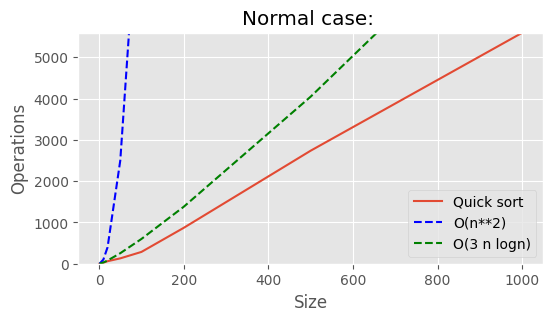

In [51]:
# 3.6 Code testing Quick sort
size = np.array([]); #this array will store the current dataset size
t_list = np.array([]); #store processing time here
oper_list = np.array([]); #store processing time here
num = 1 #evaluation repetition (keep at 1 for now)

n_list = [1,10,20,50,100, 200, 500, 1000]

s = QuickSort()
s.data_params['type'] = 0 # 1 best # 2 worst case # random

# Loop over all dataset sizes
for n in n_list:
    s.data_params['size'] = n
    result = s.run(ntimes=num)
    size = np.append(size, n)
    oper_list = np.append(oper_list, result['avg_O'])

# Plot graph
ax = plt.figure(figsize=[6,3])
plt.plot(size, oper_list, label='Quick sort')

Onlogn = [3*n*np.log10(n) for n in n_list]
On2 = [n*n for n in n_list]

plt.plot(size, On2, 'b--', label='O(n**2)')
plt.plot(size, Onlogn, 'g--', label='O(3 n logn)')

plt.ylim([0, max(oper_list)])
plt.xlabel('Size')
plt.ylabel('Operations')
plt.legend()
# plt.yscale('log')
plt.title("Normal case: ")
plt.show()


